In [1]:
import numpy as np
from os import listdir

In [2]:
from AutoencoderAPI.autoencoderKmeans import autoencoder_kmeans
from AutoencoderAPI.utils.correlation import second_order
from ExistingAlgorithms.Plot import plot_traces

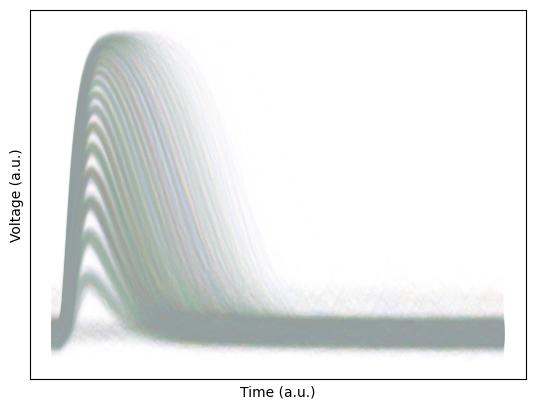

In [3]:
signal_size = 250
coherent = 'Datasets/one/'
path_test = 'Datasets/NIST (250) test/'
path_train = 'Datasets/NIST (250) train/'

X_coherent = np.concatenate([np.fromfile(f"{coherent}{fileName}",dtype=np.float16).reshape(-1,signal_size) for fileName in listdir(coherent)])
X_coherent = X_coherent.astype("double")

X_test = np.concatenate([np.fromfile(f"{path_test}{fileName}",dtype=np.float16).reshape(-1,signal_size) for fileName in listdir(path_test)])
X_test = X_test.astype("double")

X_train = np.concatenate([np.fromfile(f"{path_train}{fileName}",dtype=np.float16).reshape(-1,signal_size) for fileName in listdir(path_train)])
X_train = X_train.astype("double")

X = np.concatenate((X_test,X_train))

plot_traces(np.copy(X))

Clusters:   0%|          | 0/16 [00:00<?, ?it/s]

Number of clusters :  23
Silhouette score :  0.7040502


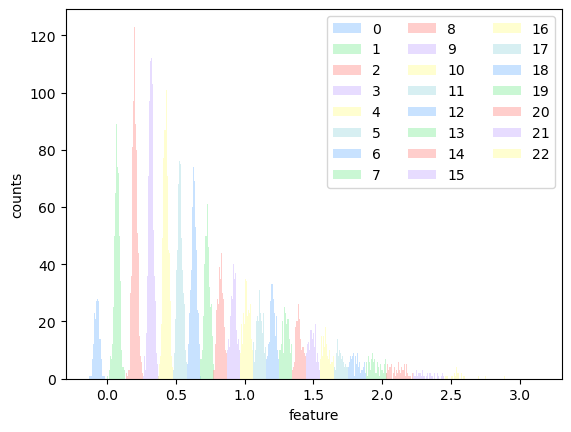

In [4]:
ak = autoencoder_kmeans("Autoencoder Log/NIST (250)/fold 0")
ak.fit_cluster(X, 15, 30, plot_clustering=True)

In [5]:
labels = ak.get_label(X_coherent)
second_order(X_coherent)

0.910705840797557